Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive gemountet. Ordner bereit.
Lade COM_CMB_IQU-smica_2048_R3.00_full.fits...


/tmp/ipykernel_9452/1904338430.py:38: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  m = hp.read_map(path, field=0, verbose=False)
/tmp/ipykernel_9452/1904338430.py:44: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  m = hp.alm2map(alm, nside, verbose=False)
    Header size is not multiple of 2880: 1048576
There may be extra bytes after the last HDU or the file is corrupted. [astropy.io.fits.hdu.hdulist]
    Header size is not multiple of 2880: 1048576
There may be extra bytes after the last HDU or the file is corrupted.


  Bereit. T_mean = 0.00 µK
Lade COM_CMB_IQU-143-fgsub-sevem_2048_R3.00_full.fits...
  Bereit. T_mean = 1.67 µK
Lade COM_CMB_IQU-217-fgsub-sevem_2048_R3.00_full.fits...
  Bereit. T_mean = -0.00 µK
83 Sparkling-Voids geladen.
2MRS geladen: 20350 Galaxien, 4070 Void-Galaxien, 4070 Filament-Galaxien.

=== Sparkling Stacking ===
SMICA: ΔT = -8.50 µK, Signifikanz = -1.14σ, N_voids = 76
143 GHz: ΔT = -8.33 µK, Signifikanz = -1.19σ, N_voids = 76
217 GHz: ΔT = -8.91 µK, Signifikanz = -1.12σ, N_voids = 76

=== Void vs. Filament (20%) ===
SMICA: T_void=-3.1 µK, T_fil=-10.5 µK, ΔT=+7.3 µK, Signifikanz=3.28σ
143 GHz: T_void=-3.1 µK, T_fil=-7.4 µK, ΔT=+4.3 µK, Signifikanz=1.98σ
217 GHz: T_void=-5.2 µK, T_fil=-10.6 µK, ΔT=+5.5 µK, Signifikanz=2.34σ


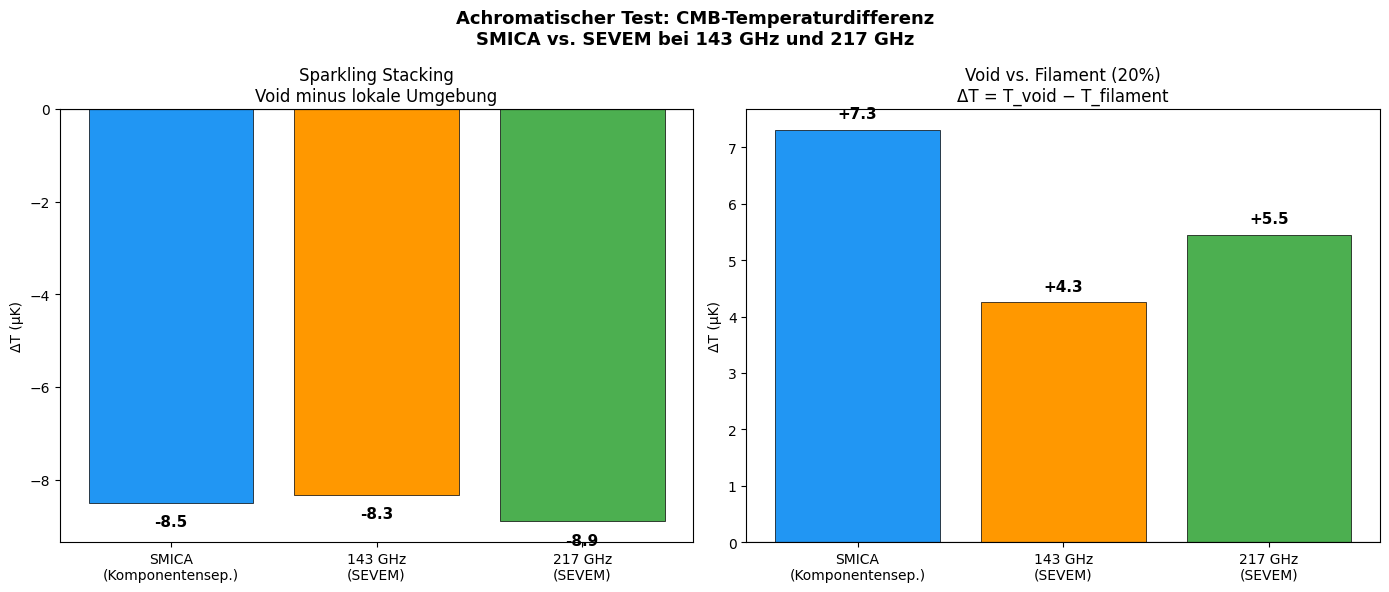

Gespeichert.
Ergebnisse gespeichert in UQSH_CMB_v2/results/


In [24]:
# ============================================================
# UQSH CMB v2 - Achromatischer Test
# Vollständiger Code
# ============================================================

# BLOCK 1: Installation und Drive
# ============================================================
!pip install healpy astroquery -q

from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.coordinates import SkyCoord
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
import os

DRIVE = '/content/drive/MyDrive'
V1    = f'{DRIVE}/UQSH_CMB'
V2    = f'{DRIVE}/UQSH_CMB_v2'
os.makedirs(f'{V2}/results', exist_ok=True)

cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

print("Drive gemountet. Ordner bereit.")


# ============================================================
# BLOCK 2: Hilfsfunktionen
# ============================================================

def load_and_prep(path, nside=512):
    print(f"Lade {path.split('/')[-1]}...")
    m = hp.read_map(path, field=0, verbose=False)
    m = hp.ud_grade(m, nside)
    alm = hp.map2alm(m, lmax=1024)
    for l in [1, 2]:
        for mm in range(l+1):
            alm[hp.Alm.getidx(1024, l, mm)] = 0
    m = hp.alm2map(alm, nside, verbose=False)
    print(f"  Bereit. T_mean = {np.mean(m)*1e6:.2f} µK")
    return m

def mpc_to_deg(r_mpc, z):
    if z < 0.001:
        z = 0.001
    d_mpc = cosmo.comoving_distance(z).value
    r_mpc_true = r_mpc / 0.7
    return np.degrees(np.arctan(r_mpc_true / d_mpc))


# ============================================================
# BLOCK 3: Karten laden
# ============================================================

nside = 512
npix  = hp.nside2npix(nside)

theta, phi = hp.pix2ang(nside, np.arange(npix))
lat  = 90 - np.degrees(theta)
mask = np.abs(lat) > 15

PATH_SMICA = f'{V1}/COM_CMB_IQU-smica_2048_R3.00_full.fits'
map_smica  = load_and_prep(PATH_SMICA)

PATH_143 = '/content/COM_CMB_IQU-143-fgsub-sevem_2048_R3.00_full.fits'
map_143  = None
if os.path.exists(PATH_143):
    map_143 = load_and_prep(PATH_143)
else:
    print("143 GHz nicht gefunden.")

PATH_217 = '/content/COM_CMB_IQU-217-fgsub-sevem_2048_R3.00_full.fits'
map_217  = None
if os.path.exists(PATH_217):
    map_217 = load_and_prep(PATH_217)
else:
    print("217 GHz nicht gefunden.")


# ============================================================
# BLOCK 4: Sparkling Voids und 2MRS laden
# ============================================================

voids = []
with open(f'{V1}/sparkling_voids.dat') as f:
    for line in f:
        if line.startswith('#') or not line.strip():
            continue
        parts = line.split()
        try:
            ra  = float(parts[1])
            dec = float(parts[2])
            z   = float(parts[3])
            r   = float(parts[4])
            voids.append((ra, dec, z, r))
        except:
            continue

print(f"{len(voids)} Sparkling-Voids geladen.")

from astroquery.vizier import Vizier
Vizier.ROW_LIMIT = -1
cat   = Vizier.get_catalogs('J/ApJS/199/26')[0]
ra_g  = np.array(cat['RAJ2000'])
dec_g = np.array(cat['DEJ2000'])
z_g   = np.array(cat['cz']) / 3e5

mask_z         = z_g < 0.03
ra_g, dec_g, z_g = ra_g[mask_z], dec_g[mask_z], z_g[mask_z]

coords = SkyCoord(ra=ra_g*u.deg, dec=dec_g*u.deg, frame='icrs')
l_g    = coords.galactic.l.deg
b_g    = coords.galactic.b.deg
mask_gal       = np.abs(b_g) > 15
ra_g, dec_g, z_g = ra_g[mask_gal], dec_g[mask_gal], z_g[mask_gal]
l_g, b_g       = l_g[mask_gal], b_g[mask_gal]

pix_g = hp.ang2pix(nside, np.radians(90-b_g), np.radians(l_g))

from scipy.spatial import cKDTree
xyz  = np.column_stack([
    np.cos(np.radians(b_g))*np.cos(np.radians(l_g)),
    np.cos(np.radians(b_g))*np.sin(np.radians(l_g)),
    np.sin(np.radians(b_g))
])
tree      = cKDTree(xyz)
dists, _  = tree.query(xyz, k=11)
d10       = dists[:, 10]

thresh     = 20
void_mask  = d10 > np.percentile(d10, 100-thresh)
fil_mask   = d10 < np.percentile(d10, thresh)

print(f"2MRS geladen: {len(ra_g)} Galaxien, "
      f"{void_mask.sum()} Void-Galaxien, "
      f"{fil_mask.sum()} Filament-Galaxien.")


# ============================================================
# BLOCK 5: Stacking-Funktion
# ============================================================

def sparkling_stacking(cmb_map, voids, mask, nside=512,
                       n_rot=500, label=""):
    void_deltas = []

    for ra, dec, z, r in voids:
        c    = SkyCoord(ra=ra*u.deg, dec=dec*u.deg, frame='icrs')
        l, b = c.galactic.l.deg, c.galactic.b.deg
        if abs(b) < 15:
            continue

        r_deg = mpc_to_deg(r, z)
        if r_deg < 0.1:
            r_deg = 0.5

        vec      = hp.ang2vec(np.radians(90-b), np.radians(l))
        pix_in   = hp.query_disc(nside, vec, np.radians(r_deg))
        pix_out  = hp.query_disc(nside, vec, np.radians(r_deg * 3.0))
        pix_ring = np.setdiff1d(pix_out, pix_in)

        if len(pix_in) < 1 or len(pix_ring) < 5:
            continue

        T_v = np.mean(cmb_map[pix_in]   * 1e6)
        T_r = np.mean(cmb_map[pix_ring] * 1e6)

        if np.isnan(T_v) or np.isnan(T_r):
            continue

        void_deltas.append(T_v - T_r)

    # nan-Filter
    void_deltas = [x for x in void_deltas if not np.isnan(x)]

    if not void_deltas:
        print(f"{label}: Keine gültigen Voids.")
        return 0, 0

    delta_T = np.mean(void_deltas)

    rot_deltas = []
    for _ in range(n_rot):
        rot_angle = np.random.uniform(10, 350)
        trial = []
        for ra, dec, z, r in voids:
            c    = SkyCoord(ra=(ra+rot_angle)*u.deg,
                            dec=dec*u.deg, frame='icrs')
            l, b = c.galactic.l.deg, c.galactic.b.deg
            if abs(b) < 15:
                continue
            r_deg    = mpc_to_deg(r, z)
            if r_deg < 0.1:
                r_deg = 0.5
            vec      = hp.ang2vec(np.radians(90-b), np.radians(l))
            pix_in   = hp.query_disc(nside, vec, np.radians(r_deg))
            pix_out  = hp.query_disc(nside, vec, np.radians(r_deg*3.0))
            pix_ring = np.setdiff1d(pix_out, pix_in)
            if len(pix_in) < 1 or len(pix_ring) < 5:
                continue
            T_v = np.mean(cmb_map[pix_in]   * 1e6)
            T_r = np.mean(cmb_map[pix_ring] * 1e6)
            if not np.isnan(T_v) and not np.isnan(T_r):
                trial.append(T_v - T_r)
        if trial:
            rot_deltas.append(np.mean(trial))

    sigma        = np.std(rot_deltas) if rot_deltas else 1
    significance = delta_T / sigma if sigma > 0 else 0

    print(f"{label}: ΔT = {delta_T:+.2f} µK, "
          f"Signifikanz = {significance:.2f}σ, "
          f"N_voids = {len(void_deltas)}")
    return delta_T, significance


# ============================================================
# BLOCK 6: Void vs. Filament Funktion
# ============================================================

def void_fil_test(cmb_map, pix_g, void_mask, fil_mask,
                  n_rot=500, label=""):
    T_void = np.mean(cmb_map[pix_g[void_mask]]) * 1e6
    T_fil  = np.mean(cmb_map[pix_g[fil_mask]])  * 1e6
    delta  = T_void - T_fil

    rot_deltas = []
    for _ in range(n_rot):
        idx_v = np.random.choice(
            np.where(mask)[0], size=void_mask.sum(), replace=False)
        idx_f = np.random.choice(
            np.where(mask)[0], size=fil_mask.sum(),  replace=False)
        rot_deltas.append(
            np.mean(cmb_map[idx_v]*1e6) -
            np.mean(cmb_map[idx_f]*1e6))

    sigma        = np.std(rot_deltas)
    significance = delta / sigma if sigma > 0 else 0

    print(f"{label}: T_void={T_void:+.1f} µK, "
          f"T_fil={T_fil:+.1f} µK, "
          f"ΔT={delta:+.1f} µK, "
          f"Signifikanz={significance:.2f}σ")
    return delta, significance


# ============================================================
# BLOCK 7: Alle Tests ausführen
# ============================================================

print("\n=== Sparkling Stacking ===")
dT_smica,    sig_stack_smica = sparkling_stacking(
    map_smica, voids, mask, label="SMICA")

dT_143    = None
dT_217    = None
sig_143   = None
sig_217   = None

if map_143 is not None:
    dT_143, sig_143 = sparkling_stacking(
        map_143, voids, mask, label="143 GHz")

if map_217 is not None:
    dT_217, sig_217 = sparkling_stacking(
        map_217, voids, mask, label="217 GHz")

print("\n=== Void vs. Filament (20%) ===")
dT_vf_smica, sig_vf_smica = void_fil_test(
    map_smica, pix_g, void_mask, fil_mask, label="SMICA")

dT_vf_143    = None
dT_vf_217    = None

if map_143 is not None:
    dT_vf_143, sig_vf_143 = void_fil_test(
        map_143, pix_g, void_mask, fil_mask, label="143 GHz")

if map_217 is not None:
    dT_vf_217, sig_vf_217 = void_fil_test(
        map_217, pix_g, void_mask, fil_mask, label="217 GHz")


# ============================================================
# BLOCK 8: Plot
# ============================================================

# BLOCK 8: Plot korrigiert
karten_labels = ['SMICA\n(Komponentensep.)', '143 GHz\n(SEVEM)', '217 GHz\n(SEVEM)']
farben = ['#2196F3', '#FF9800', '#4CAF50']

werte_stack = [dT_smica]
werte_vf    = [dT_vf_smica]
labels_stack = ['SMICA\n(Komponentensep.)']
labels_vf    = ['SMICA\n(Komponentensep.)']

if dT_143 is not None:
    werte_stack.append(dT_143)
    werte_vf.append(dT_vf_143)
    labels_stack.append('143 GHz\n(SEVEM)')
    labels_vf.append('143 GHz\n(SEVEM)')

if dT_217 is not None:
    werte_stack.append(dT_217)
    werte_vf.append(dT_vf_217)
    labels_stack.append('217 GHz\n(SEVEM)')
    labels_vf.append('217 GHz\n(SEVEM)')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Stacking
axes[0].bar(labels_stack, werte_stack,
            color=farben[:len(werte_stack)],
            edgecolor='black', linewidth=0.5)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_ylabel('ΔT (µK)')
axes[0].set_title('Sparkling Stacking\nVoid minus lokale Umgebung')
for i, v in enumerate(werte_stack):
    offset = 0.2 if v >= 0 else -0.5
    axes[0].text(i, v + offset, f'{v:+.1f}',
                 ha='center', fontsize=11, fontweight='bold')

# Plot 2: Void vs. Filament
axes[1].bar(labels_vf, werte_vf,
            color=farben[:len(werte_vf)],
            edgecolor='black', linewidth=0.5)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_ylabel('ΔT (µK)')
axes[1].set_title('Void vs. Filament (20%)\nΔT = T_void − T_filament')
for i, v in enumerate(werte_vf):
    offset = 0.2 if v >= 0 else -0.5
    axes[1].text(i, v + offset, f'{v:+.1f}',
                 ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Achromatischer Test: CMB-Temperaturdifferenz\n'
             'SMICA vs. SEVEM bei 143 GHz und 217 GHz',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{V2}/results/plot_achromatisch.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Gespeichert.")


# ============================================================
# BLOCK 9: Ergebnisse speichern
# ============================================================

with open(f'{V2}/results/ergebnisse_achromatisch.txt', 'w') as f:
    f.write("Achromatischer Test — UQSH CMB v2\n")
    f.write("="*45 + "\n\n")
    f.write("Sparkling Stacking (Void minus lokale Umgebung):\n")
    f.write(f"  SMICA:   ΔT = {dT_smica:+.2f} µK, "
            f"Signifikanz = {sig_stack_smica:.2f}σ\n")
    if dT_143 is not None:
        f.write(f"  143 GHz: ΔT = {dT_143:+.2f} µK, "
                f"Signifikanz = {sig_143:.2f}σ\n")
    if dT_217 is not None:
        f.write(f"  217 GHz: ΔT = {dT_217:+.2f} µK, "
                f"Signifikanz = {sig_217:.2f}σ\n")
    f.write("\nVoid vs. Filament (20%):\n")
    f.write(f"  SMICA:   ΔT = {dT_vf_smica:+.1f} µK, "
            f"Signifikanz = {sig_vf_smica:.2f}σ\n")
    if dT_vf_143 is not None:
        f.write(f"  143 GHz: ΔT = {dT_vf_143:+.1f} µK, "
                f"Signifikanz = {sig_vf_143:.2f}σ\n")
    if dT_vf_217 is not None:
        f.write(f"  217 GHz: ΔT = {dT_vf_217:+.1f} µK, "
                f"Signifikanz = {sig_vf_217:.2f}σ\n")

print("Ergebnisse gespeichert in UQSH_CMB_v2/results/")